# Chest X-Ray Preprocessing Pipeline

**Project:** Pneumonia Detection using Deep Learning  
**Objective:** Prepare raw chest X-ray images for our model  

## Table of Contents

1. **Libraries & Configuration:** Set up the tools and file locations.
2. **Dataset Analysis:** Check how many healthy and infected images we have.
3. **Technique Analysis:** Compare different image editing techniques to pick the best ones.
4. **Final Pipeline:** Build the final step-by-step image processor.
5. **Processing & Execution:** Run the processor on all our images.
6. **Visualization & Verification:** Double-check that our images look correct.

## 1. Libraries & Configuration

### 1.1 Import Libraries

Here we load the basic tools we need. We use OpenCV for image editing, NumPy for numbers, Matplotlib for drawing graphs, and tqdm to show progress bars.

In [28]:
import os
import cv2
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
from tqdm import tqdm

### 1.2 Configuration

These are the instructions for where to find the original images and where to save the edited ones. We save them as special number files (.npy) instead of normal image files (like .png) because it keeps our math exact.

In [29]:
# Input Folders
DATASET_DIR = 'chest_xray/train/'
VAL_DIR     = 'chest_xray/val/'
TEST_DIR    = 'chest_xray/test/'

# Output Folders
OUTPUT_DIR      = 'chest_xray/train_processed/'
VAL_OUTPUT_DIR  = 'chest_xray/val_processed/'
TEST_OUTPUT_DIR = 'chest_xray/test_processed/'

# Class Folders
NORMAL_DIR    = os.path.join(DATASET_DIR, 'NORMAL')
PNEUMONIA_DIR = os.path.join(DATASET_DIR, 'PNEUMONIA')

OUT_NORMAL    = os.path.join(OUTPUT_DIR, 'NORMAL')
OUT_PNEUMONIA = os.path.join(OUTPUT_DIR, 'PNEUMONIA')

# Settings
TARGET_SIZE   = (128, 128)
SUPPORTED_EXT = ('.jpg', '.jpeg', '.png', '.bmp')

## 2. Dataset Analysis

### 2.1 Count Images per Class

A simple tool to count how many images are in a given folder.

In [30]:
def count_images(folder):
    return [
        f for f in os.listdir(folder)
        if f.lower().endswith(SUPPORTED_EXT)
    ]

### 2.2 Balance Check

Before we start, we need to know if we have roughly the same number of healthy and infected lung images. If one group is much larger, the model might get confused during training and just guess the larger group all the time.

In [31]:
normal_files    = count_images(NORMAL_DIR)
pneumonia_files = count_images(PNEUMONIA_DIR)
normal_count    = len(normal_files)
pneumonia_count = len(pneumonia_files)

print("DATASET ANALYSIS")
print(f"  NORMAL    images : {normal_count}")
print(f"  PNEUMONIA images : {pneumonia_count}")
print(f"  Difference       : {abs(normal_count - pneumonia_count)}")

if normal_count == pneumonia_count:
    print("  Status: Balanced")
    NEEDS_AUGMENTATION = False
else:
    minority      = 'NORMAL' if normal_count < pneumonia_count else 'PNEUMONIA'
    majority_count = max(normal_count, pneumonia_count)
    minority_count = min(normal_count, pneumonia_count)
    needed        = majority_count - minority_count
    print(f"  Status: IMBALANCED. We have less {minority} images.")
    NEEDS_AUGMENTATION = True

DATASET ANALYSIS
  NORMAL    images : 1341
  PNEUMONIA images : 3875
  Difference       : 2534
  Status: IMBALANCED. We have less NORMAL images.


## 3. Technique Analysis

We tested 23 different ways to edit our X-ray images. For each one, we show the image and a graph called a histogram. The histogram helps us see how bright or dark the picture is overall.

### 3.1 Baseline: Original Image

![Original](results/orginal.png)

This is exactly how the picture comes from the hospital.

**What the graph shows:** 
The big spike on the left (at 0) is the empty black space around the patient. All the important details (lungs, bones) are bunched up in the middle. The right side is totally empty, meaning the picture is a bit dull and lacks bright whites.

### 3.2 Adjusting Brightness Scales (Normalization)

**Min-Max Normalization**  
![Min-Max](results/minmax.png)  
This takes the darkest pixel and makes it exactly 0, and the brightest pixel and makes it exactly 1. The shape of the graph stays the same, just the numbers on the bottom change.

**Z-Score Normalization**  
![Z-Score](results/zscore.png)  
This shift the brightness so the average color is exactly 0. Pixels brighter than average become positive numbers, and pixels darker than average become negative numbers.

**Our Choice: Z-Score**  
We chose Z-Score because the model we are going to use works best when the average is set to 0.

### 3.3 Cleaning Up Grainy Images (Denoising)

**Non-Local Means**  
![Non-Local Means](results/nonLocalMeans.png)  
A smart tool that searches the whole image for similar spots to decide how to clean up dirt. It bunches similar colors together.

**Bilateral Filtering**  
![Bilateral Filter](results/bilateral.png)  
This smooths the picture while trying to keep the edges of the bones sharp.

**Gaussian Blur**  
![Gaussian Blur](results/gaussian.png)  
This averages nearby pixels together in a smooth circle. It leaves the graph looking very round and melty.

**Median Blur**  
![Median Blur](results/median.png)  
This looks at all nearby pixels and just picks the middle value. It is amazing at removing random black or white dots (like salt and pepper).

**Mean Blur**  
![Mean Blur](results/mean.png)  
Just a basic average of nearby pixels. It makes the image very blurry and loses too much detail.

**Our Choice: Median Blur**  
We picked Median Blur because it removes the bad dots while keeping the edges of the lungs sharp.

### 3.4 Making Edges Sharper

**Unsharp Masking**  
![Unsharp Masking](results/unsharp.png)   
This forces light pixels to be lighter and dark pixels to be darker to make edges stand out. It makes the graph look like a comb with missing teeth.

**Laplacian Sharpening**  
![Laplacian Sharpening](results/laplacian_sharp.png)  
A more extreme version of sharpening.

**Our Choice: Skip Sharpening**  
We avoid these methods because it makes the graininess look worse. For medical images, drawing fake lines can trick the model into thinking it sees an illness that isn't there.

### 3.5 Finding Outlines (Edge Detection)

**Sobel, Laplacian, and Canny Tools**  
![Sobel](results/sobel.png)  
![Laplacian](results/laplacian_edge_detection.png)  
![Canny](results/canny.png)  

These tools turn the image mostly black and only draw white lines where bones or the heart stop and start.
- Sobel detects edges by calculating the gradient of pixel intensity, highlighting areas where brightness changes sharply
- Laplacian detects edges by taking the second derivative of the image, marking spots where the gradient itself changes direction
- Canny is the most advanced of the three; it first applies Sobel to find gradients, then uses additional steps like noise filtering and threshold checks to produce clean, precise edges

**Our Choice: Skip**  
We must skip these tools. Pneumonia looks like a soft cloud in the lungs. If we only keep the sharp outlines of the bones, we delete the very thing we are trying to find!.

### 3.6 Making Hidden Things Visible (Contrast)

**Global Histogram Equalization**  
![Histogram Equalization](results/histogram_eq.png)  
This stretches out the dull colors to make the image jump out at you, but it often stretches things too much and makes it look harsh.

**CLAHE**  
![CLAHE](results/chahe.png)  
This breaks the image into tiny blocks and fixes the brightness block-by-block. It is very smart and stops the image from getting too bright.

**Our Choice: CLAHE**  
CLAHE is the best choice for medical images. It safely brings out hidden details in the dark parts of the lungs.

### 3.7 Resizing the Images

The hospital gives us giant images, but our model needs small squares. We have different math ways (called interpolation) to shrink them.

- **Linear**: Fast and pretty good.<br>
![Linear](results/linear.png)

- **Cubic**: Very smooth and high quality.<br>
![Cubic](results/cubic.png)

- **Area**: Best for making things smaller.<br>
![Area](results/area.png)

- **Nearest**: Just chops pixels out. Looks very blocky.<br>
![Nearest](results/nearest.png)

**Our Choice: Cubic Interpolation**
We use Cubic because it keeps the soft shadows in the lungs looking smooth as the image gets smaller.

### 3.8 Data Augmentation

We have too many infected patient images and not enough healthy patient images, we can flip or tilt the healthy ones to create new fake images. 

- **Flip Left/Right**: Safe, because human lungs look the same on both sides.
- **Small Tilts**: Simulates the patient standing a little crooked.
- **Brightness Changes**: Simulates different hospital machines.

**Our Choice:** Skipping Data augmentation <br>
Instead of creating fake images, we will just adjust the weights so, model can learn accurately.

## 4. Final Pipeline

### 4.1 Core Processing Tool

Here we combine our chosen steps into one tool that we can apply to every picture.

Original -> Resize Cubic -> Median Blur -> CLAHE Contrast -> Z-Score Math -> Save

In [ ]:
def preprocess_image(img_path, target_size=TARGET_SIZE):
    
    # 1. Open the image in black and white
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    # 2. Resizing
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_CUBIC)

    # 3. Median Blur to reduce noise
    img = cv2.medianBlur(img, 3)

    # 4. CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)

    # 5. Normalization (Z-score)
    img  = img.astype(np.float32)
    mean = np.mean(img)
    std  = np.std(img)
    if std == 0:
        std = 1  
    img = (img - mean) / std

    return img

### 4.2 Save Tool

We save our files as numpy math files so we don't accidentally ruin the exact Z-Score numbers we just created.

In [33]:
def save_as_npy(img_array, save_path):
    np.save(str(save_path), img_array.astype(np.float32))

## 5. Processing & Execution

### 5.1 Process a Single Folder

This runs our tool on one folder at a time.

In [34]:
def process_class(src_dir, out_dir, class_name):
    os.makedirs(out_dir, exist_ok=True)
    files = [f for f in os.listdir(src_dir) if f.lower().endswith(SUPPORTED_EXT)]

    print(f"\n  Processing {class_name} ({len(files)} images)...")
    saved = []

    for fname in tqdm(files, desc=f"    {class_name}"):
        src_path  = os.path.join(src_dir, fname)
        save_name = f"{Path(fname).stem}_preprocessed.npy"
        save_path = os.path.join(out_dir, save_name)
        try:
            save_as_npy(preprocess_image(src_path), save_path)
            saved.append(save_path)
        except Exception as e:
            print(f"  ERROR: {fname} : {e}")

    print(f"  Done. {len(saved)} files saved to {out_dir}")
    return saved

### 5.2 Process Main Folders

This runs our tool for Training data, Validation data, and Testing data.

In [35]:
def process_split(split_dir, output_dir, split_name):
    print(f"\n Processing {split_name} split ")

    for class_name in ['NORMAL', 'PNEUMONIA']:
        src  = os.path.join(split_dir,  class_name)
        dest = os.path.join(output_dir, class_name)

        if not os.path.exists(src):
            print(f"  WARNING: {src} not found. skipping")
            continue

        files = [f for f in os.listdir(src) if f.lower().endswith(SUPPORTED_EXT)]
        os.makedirs(dest, exist_ok=True)
        print(f"  {class_name}: {len(files)} images")

        for fname in tqdm(files, desc=f"    {class_name}"):
            src_path  = os.path.join(src, fname)
            save_path = os.path.join(dest, f"{Path(fname).stem}_p.npy")
            try:
                save_as_npy(preprocess_image(src_path), save_path)
            except Exception as e:
                print(f"  ERROR: {fname} : {e}")

    # Print counts at the end
    for class_name in ['NORMAL', 'PNEUMONIA']:
        dest  = os.path.join(output_dir, class_name)
        count = len([f for f in os.listdir(dest) if f.endswith('.npy')]) if os.path.exists(dest) else 0
        print(f"  {split_name} {class_name}: {count} files")

## 6. Visualization & Verification

### 6.1 Visualize Process

This tool lets us look at an image going through our process step by step.

In [36]:
def visualize_preprocessing_steps(img_path, save_fig=True):
    img_orig    = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img_orig, TARGET_SIZE, interpolation=cv2.INTER_CUBIC)
    img_median  = cv2.medianBlur(img_resized, 3)
    clahe       = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe   = clahe.apply(img_median)
    img_zscore  = (img_clahe.astype(np.float32) - img_clahe.mean()) / (img_clahe.std() + 1e-7)

    steps = [
        ('1. Original',                 img_orig),
        ('2. Resized',                  img_resized),
        ('3. Cleared Noise',            img_median),
        ('4. Enhanced Shadows',         img_clahe),
        ('5. Ready for Training',       img_zscore),
    ]

    fig, axes = plt.subplots(2, len(steps), figsize=(20, 7))
    fig.suptitle('Image Pipeline', fontsize=13, fontweight='bold')

    for col, (title, image) in enumerate(steps):
        axes[0, col].imshow(image, cmap='gray')
        axes[0, col].set_title(title, fontsize=9)
        axes[0, col].axis('off')
        axes[1, col].hist(image.ravel(), bins=100, color='black', alpha=0.75)
        axes[1, col].set_xlabel('Light Value')

    plt.tight_layout()
    if save_fig:
        path = os.path.join(OUTPUT_DIR, 'preprocessing_pipeline_visualization.png')
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f"Saved a picture of this process to: {path}")
    plt.show()

### 6.2 Chart Our Images

This tool creates a bar chart so we can easily see if our dataset is unbalanced.

In [37]:
def visualize_class_balance(before_normal, before_pneumonia,
                             after_normal, after_pneumonia, save_fig=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Image Totals', fontsize=13, fontweight='bold')
    categories = ['HEALTHY', 'PNEUMONIA']

    for ax, counts, title in zip(
        axes,
        [[before_normal, before_pneumonia], [after_normal, after_pneumonia]],
        ['Before Processing', 'After Processing']
    ):
        ax.bar(categories, counts, color=['steelblue', 'tomato'], width=0.5)
        ax.set_title(title)
        ax.set_ylabel('Total Count')
        for i, v in enumerate(counts):
            ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    if save_fig:
        path = os.path.join(OUTPUT_DIR, 'class_balance_chart.png')
        plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

### 6.3 Verify pre processed files

This tool takes a few images we made and makes sure the average brightness is zero.

In [38]:
def verify_npy_stats(output_dir, split_name, n=10):
    for class_name in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(output_dir, class_name)
        if not os.path.exists(folder):
            continue
        files  = [f for f in os.listdir(folder) if f.endswith('.npy')][:n]
        means  = [np.load(os.path.join(folder, f)).mean() for f in files]
        stds   = [np.load(os.path.join(folder, f)).std()  for f in files]
        print(f"  {split_name} {class_name} - Average: {np.mean(means):.3f} (Should be 0.0)")

## 6.4 The Final Run

This runs everything we just built.

Starting Image Setup Pipeline!
Saved a picture of this process to: chest_xray/train_processed/preprocessing_pipeline_visualization.png


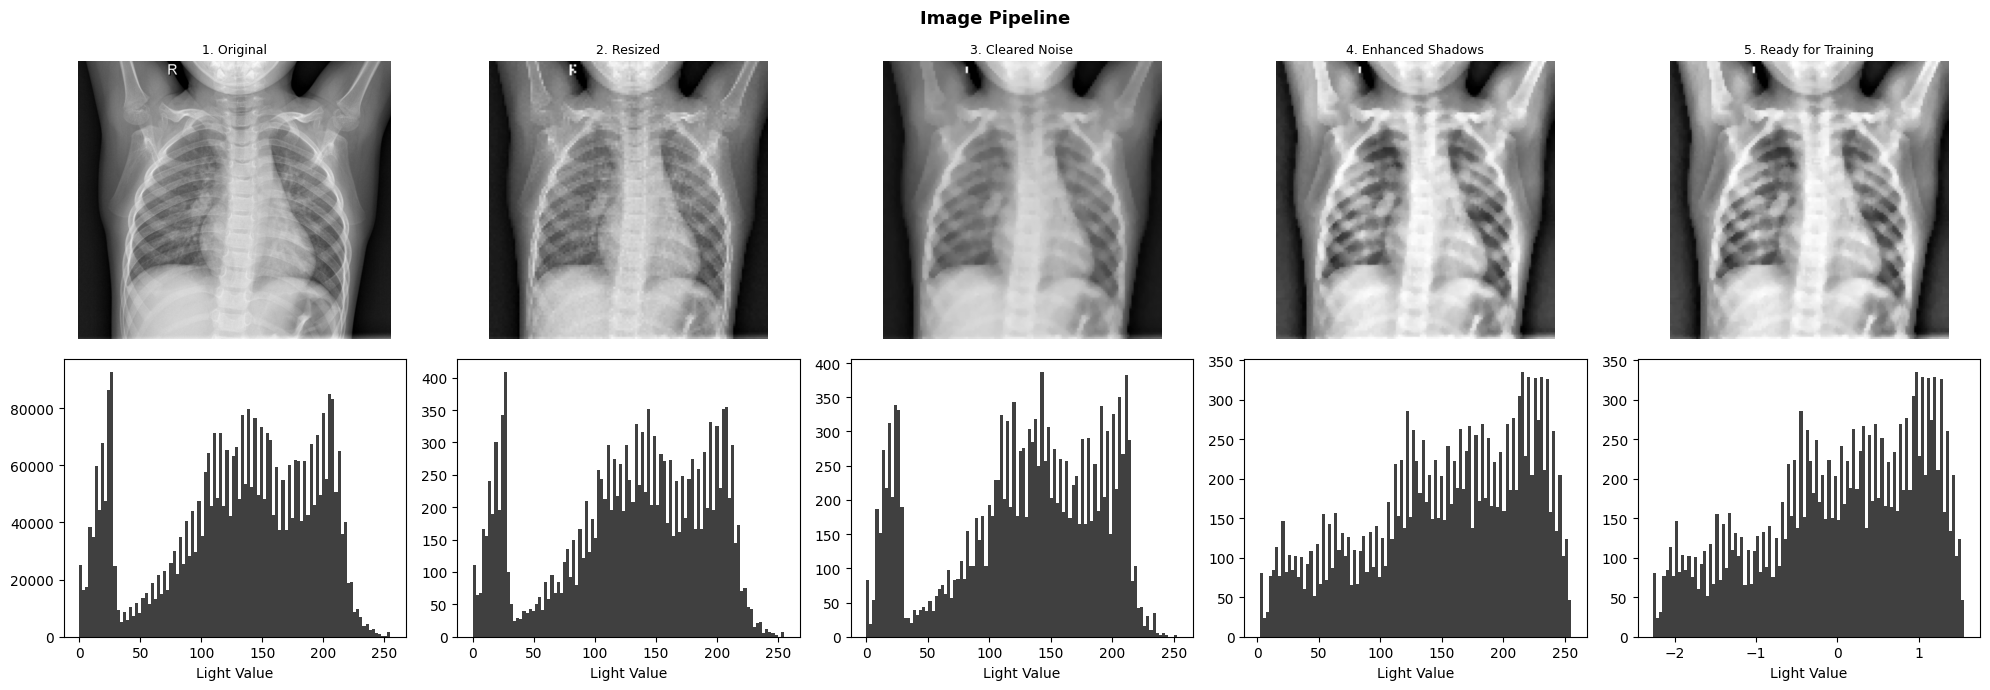


  Processing NORMAL (1341 images)...


    NORMAL: 100%|██████████| 1341/1341 [00:16<00:00, 83.07it/s] 


  Done. 1341 files saved to chest_xray/train_processed/NORMAL

  Processing PNEUMONIA (3875 images)...


    PNEUMONIA: 100%|██████████| 3875/3875 [00:53<00:00, 71.82it/s]


  Done. 3875 files saved to chest_xray/train_processed/PNEUMONIA

 Processing VAL split 
  NORMAL: 8 images


...

  VAL NORMAL: 8 files
  VAL PNEUMONIA: 8 files

 Processing TEST split 
  NORMAL: 234 images


    NORMAL: 100%|██████████| 234/234 [00:04<00:00, 49.36it/s]


  PNEUMONIA: 390 images


    PNEUMONIA: 100%|██████████| 390/390 [00:05<00:00, 75.61it/s]


  TEST NORMAL: 234 files
  TEST PNEUMONIA: 390 files
  TRAIN NORMAL - Average: 0.000 (Should be 0.0)
  TRAIN PNEUMONIA - Average: 0.000 (Should be 0.0)
  VAL NORMAL - Average: -0.000 (Should be 0.0)
  VAL PNEUMONIA - Average: 0.000 (Should be 0.0)
  TEST NORMAL - Average: -0.000 (Should be 0.0)
  TEST PNEUMONIA - Average: 0.000 (Should be 0.0)


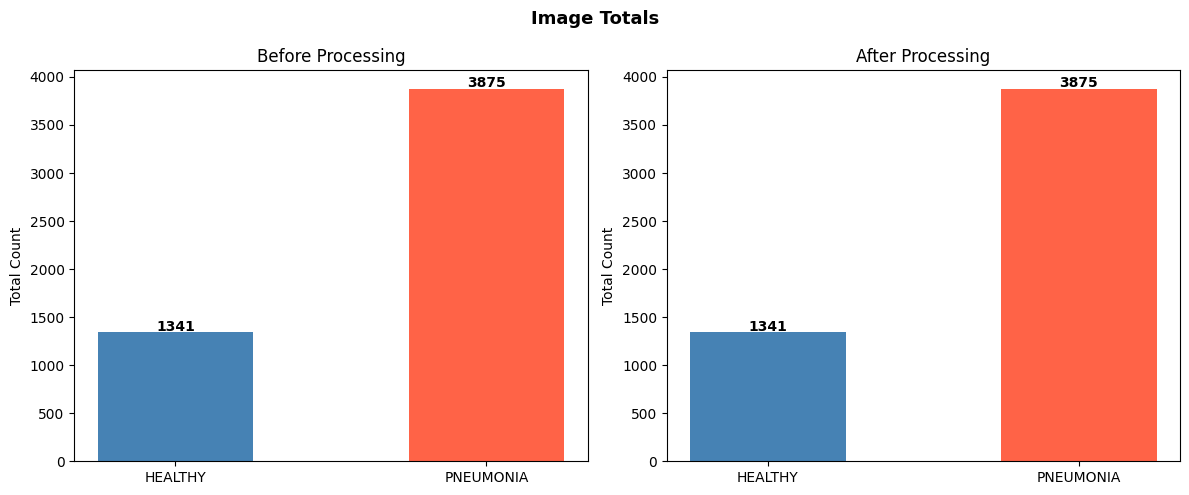

Finished!


In [ ]:
print("Starting Image Setup Pipeline!")

# Clear out old runs
for d in [OUTPUT_DIR, VAL_OUTPUT_DIR, TEST_OUTPUT_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)

os.makedirs(OUT_NORMAL,    exist_ok=True)
os.makedirs(OUT_PNEUMONIA, exist_ok=True)

# Showing an example
sample_normal = os.path.join(NORMAL_DIR, normal_files[0])
visualize_preprocessing_steps(sample_normal)

# Running images
process_class(NORMAL_DIR,    OUT_NORMAL,    'NORMAL')
process_class(PNEUMONIA_DIR, OUT_PNEUMONIA, 'PNEUMONIA')
process_split(VAL_DIR, VAL_OUTPUT_DIR, 'VAL')
process_split(TEST_DIR, TEST_OUTPUT_DIR, 'TEST')

# Verify the preservation of the math shift
verify_npy_stats(OUTPUT_DIR,      'TRAIN')
verify_npy_stats(VAL_OUTPUT_DIR,  'VAL')
verify_npy_stats(TEST_OUTPUT_DIR, 'TEST')

# Charts
final_normal    = len([f for f in os.listdir(OUT_NORMAL)    if f.endswith('.npy')])
final_pneumonia = len([f for f in os.listdir(OUT_PNEUMONIA) if f.endswith('.npy')])

visualize_class_balance(
    before_normal    = normal_count,
    before_pneumonia = pneumonia_count,
    after_normal     = final_normal,
    after_pneumonia  = final_pneumonia
)

print("Finished!")